# **HEALTHCONNECT CLINIC DATA ANAYSIS**
## Exploratory Analysis, KPI Development and Business Insights

**Project :** Improving patient appointment attendance and healthcare support using Data and AI.

**Objective :** To analyse appointment attendance and no-show patterns, calculate selected KPIs, investigate important relationships in the data, and develop evidence-based business recommendations.

## 1. Week 04 to 05  Project Continuity 
During week 04, the HealthConnect business problem, relevant project resources, data-quality issues, analytical questions and potential KPIs were identified. 

Week 05 builds directly on that foundation by completing data preparation, performing exploratory data analysis, calculating selected KPIs, interpreting the findings and developing initial business recommendations.

## 2. Importing Libraries and Loading the Data 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data_cleaned.csv")

In [4]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [5]:
df.shape

(5000, 18)

## 3. Data Cleaning and Preparation

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

The processed Week 4 dataset was successfully loaded and will serve as the starting point for the week 5 analysis. 

In [7]:
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [8]:
pd.crosstab(df["reminder_sent"], df["reminder_channel"], dropna=False)

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


In [9]:
df["reminder_channel"] = df["reminder_channel"].fillna("No Reminder")

In [10]:
df["reminder_channel"].value_counts(dropna=False)

reminder_channel
SMS            2000
No Reminder    1366
WhatsApp       1101
Email           533
Name: count, dtype: int64

In [11]:
df["distance_to_clinic_km"].describe()

count    4910.000000
mean       10.109572
std         6.590030
min         0.500000
25%         5.300000
50%         8.700000
75%        13.500000
max        45.000000
Name: distance_to_clinic_km, dtype: float64

In [21]:
distance_median = df["distance_to_clinic_km"].median()
df["distance_to_clinic_km"]= df["distance_to_clinic_km"].fillna("distance_median") 

In [12]:
df["distance_to_clinic_km"].value_counts(dropna=False)

distance_to_clinic_km
NaN     90
5.8     49
8.2     47
4.8     45
5.9     45
        ..
36.5     1
24.0     1
26.9     1
35.3     1
37.0     1
Name: count, Length: 336, dtype: int64

In [13]:
df["distance_to_clinic_km"].isnull().sum()

np.int64(90)

In [14]:
df["waiting_time_minutes"].describe()

count    4940.000000
mean       24.189676
std        10.863184
min         2.000000
25%        17.000000
50%        24.000000
75%        32.000000
max        68.000000
Name: waiting_time_minutes, dtype: float64

In [15]:
df["distance_to_clinic_km"]=df["distance_to_clinic_km"].astype(float)

In [16]:
df["waiting_time_minutes"] = df["waiting_time_minutes"].fillna(df["waiting_time_minutes"].median())

In [17]:
df["waiting_time_minutes"].isnull().sum()

np.int64(0)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       5000 non-null   object 
 15  dist

In [19]:
df.duplicated().sum()

np.int64(0)

## 4. Data Preparation Summary

The week 04 dataset was used as the starting point for Week 05. 

The dataset was rechecked for : 
- Missing values
- Duplicate records
- Data types

The missing values were treated accordingly by creating a "No Reminder" section for reminder channel, and by filling in with median for distance_to_clinic and waiting_time_minutes columns. The clean dataset was saved successfully.

In [20]:
df.to_csv("Week5_clean_dataset.csv")

## 5. Exploratory Data Analysis

The exploratory analysis focuses on appointment attendance and no-show patterns and examines relationships between appointment outcomes and relevant patient, appointment and historical characteristics.

### a. Outcome Distribution 

In [21]:
df["appointment_outcome"].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

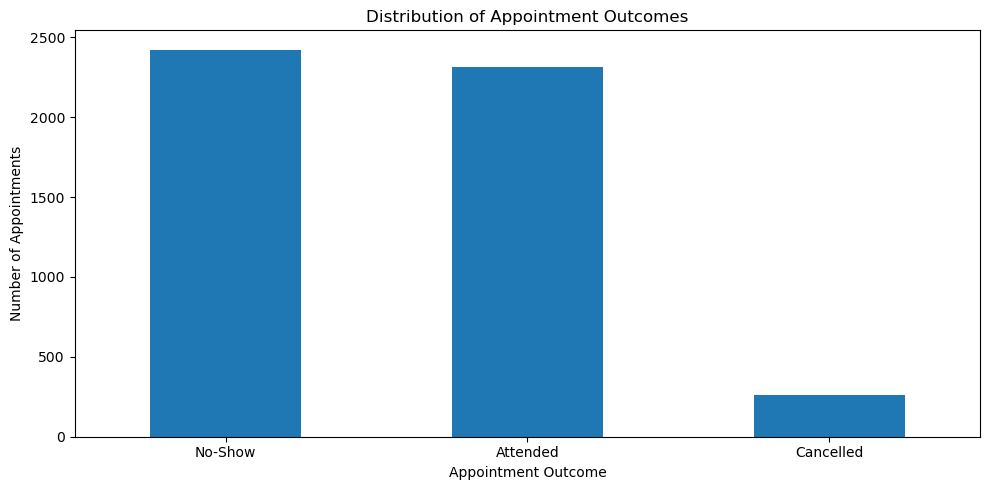

In [22]:
df["appointment_outcome"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Distribution of Appointment Outcomes")
plt.xlabel("Appointment Outcome")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
df["appointment_outcome"].value_counts(normalize=True) * 100

appointment_outcome
No-Show      48.46
Attended     46.28
Cancelled     5.26
Name: proportion, dtype: float64

### b. Appointment Type vs Outcome

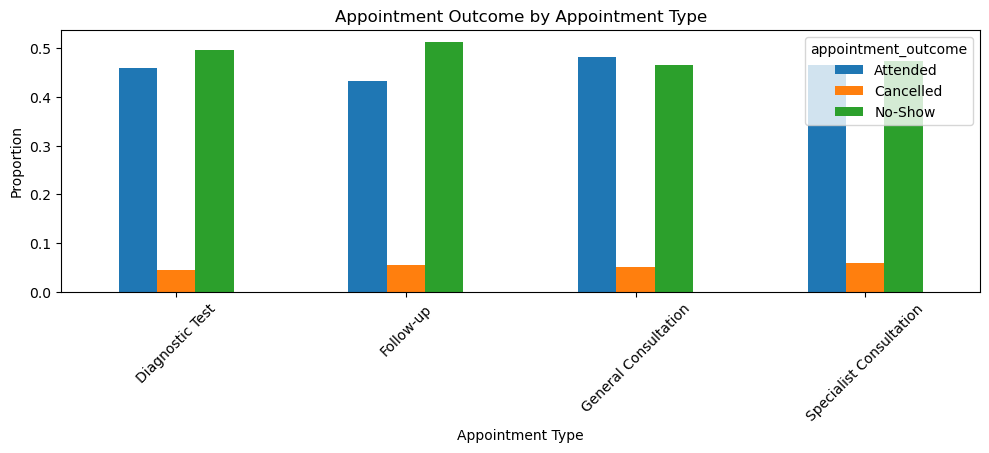

In [24]:
pd.crosstab(df["appointment_type"], df["appointment_outcome"], normalize="index").plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Appointment Outcome by Appointment Type")
plt.xlabel("Appointment Type")
plt.ylabel("Proportion")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [25]:
pd.crosstab(df["appointment_type"], df["appointment_outcome"], normalize="index") * 100

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,45.868465,4.384486,49.747049
Follow-up,43.349754,5.418719,51.231527
General Consultation,48.274209,5.081496,46.644295
Specialist Consultation,46.555556,6.000000,47.444444


### c. Reminder sent vs Outcome

In [26]:
reminder_outcome = pd.crosstab(df["reminder_sent"], df["appointment_outcome"], normalize="index") * 100
reminder_outcome

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,42.679356,5.929722,51.390922
Yes,47.633462,5.008255,47.358283


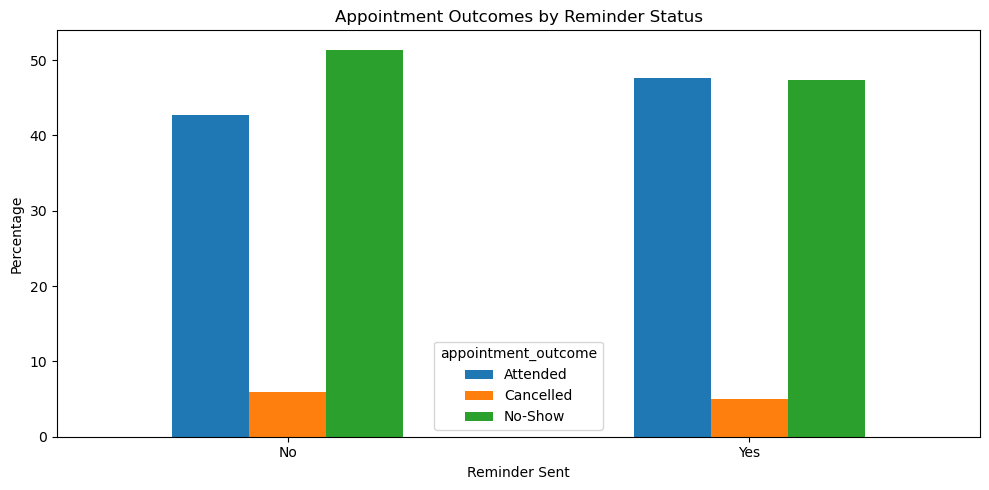

In [27]:
reminder_outcome.plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Appointment Outcomes by Reminder Status")
plt.xlabel("Reminder Sent")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### d. Reminder Channel vs Outcome

In [28]:
channel_outcome= pd.crosstab(df["reminder_channel"], df["appointment_outcome"], normalize="index") *100
channel_outcome

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,46.529081,5.065666,48.405253
No Reminder,42.679356,5.929722,51.390922
SMS,49.600000,4.650000,45.750000
WhatsApp,44.595822,5.631244,49.772934


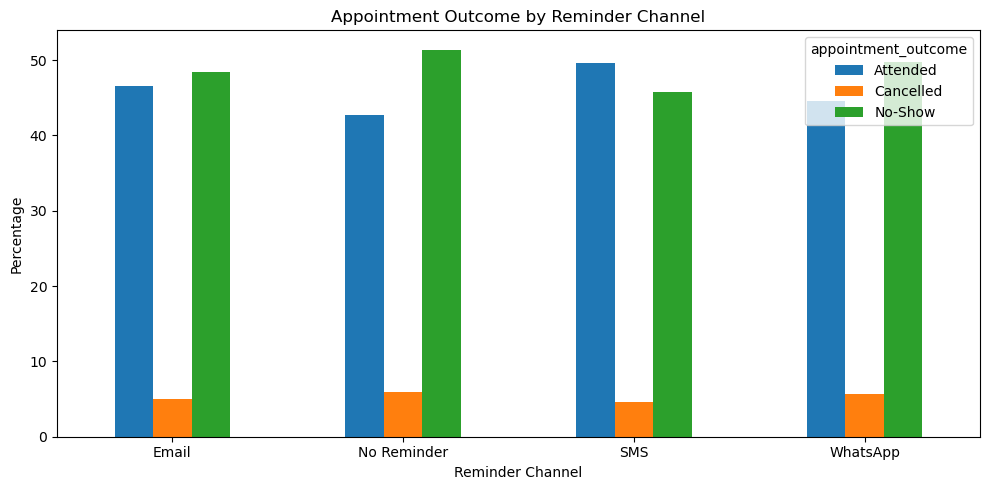

In [29]:
channel_outcome.plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Appointment Outcome by Reminder Channel")
plt.xlabel("Reminder Channel")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### e. Previous no-shows vs Outcome

In [30]:
no_show_outcome=pd.crosstab(df["previous_no_shows"], df["appointment_outcome"], normalize="index") * 100
no_show_outcome 

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,50.462170,6.025334,43.512496
1,42.248062,4.263566,53.488372
2,36.301370,4.337900,59.360731
3,29.487179,2.564103,67.948718
4,33.333333,0.000000,66.666667
5,0.000000,0.000000,100.000000


### f. Distance vs Outcome

In [31]:
df.groupby("appointment_outcome")["distance_to_clinic_km"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
appointment_outcome,,,,
Attended,9.668703,8.3,0.5,45.0
Cancelled,10.111583,9.1,0.6,35.4
No-Show,10.531481,9.1,0.5,45.0


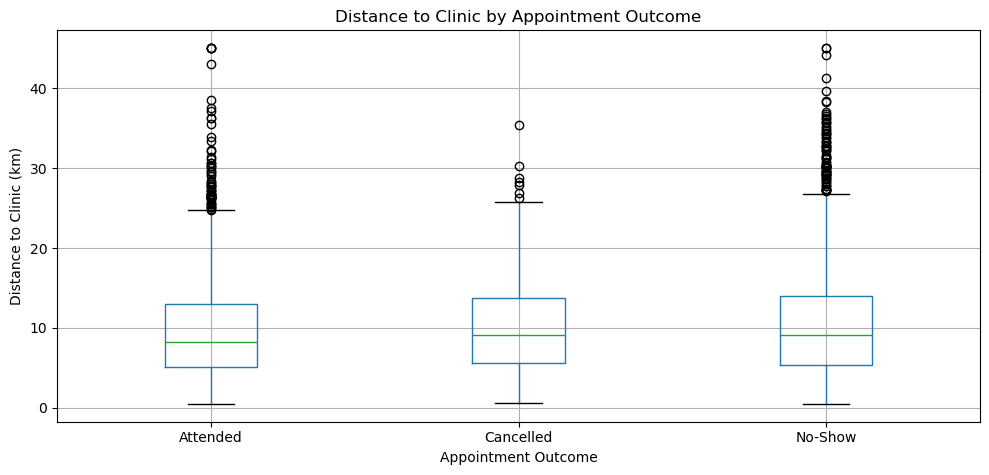

In [34]:
df.boxplot(
    column="distance_to_clinic_km", 
    by="appointment_outcome",
    figsize=(10,5)
)
plt.title("Distance to Clinic by Appointment Outcome")
plt.suptitle("")
plt.xlabel("Appointment Outcome")
plt.ylabel("Distance to Clinic (km)")
plt.tight_layout()
plt.show()

### g. Waiting Time vs Outcome

In [33]:
df.groupby("appointment_outcome")["waiting_time_minutes"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
appointment_outcome,,,,
Attended,24.286517,24.0,2.0,68.0
Cancelled,23.220532,22.0,2.0,55.0
No-Show,24.197689,24.0,2.0,67.0


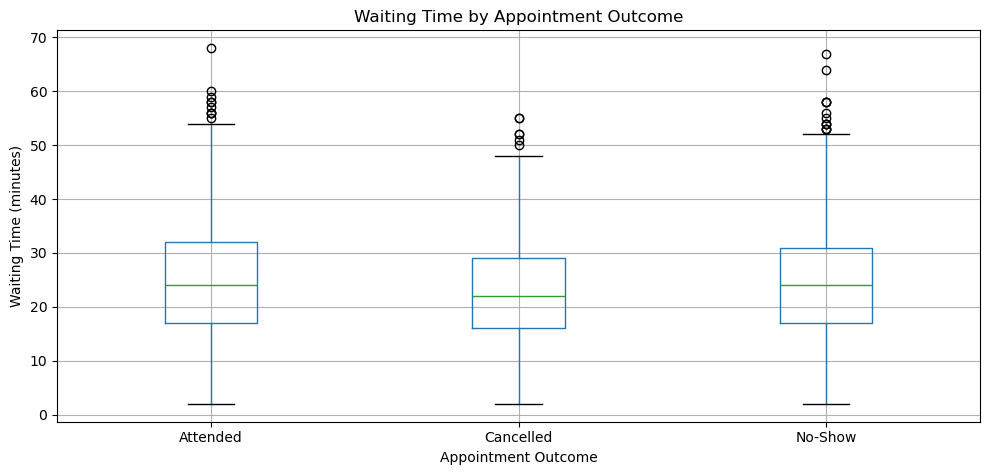

In [35]:
df.boxplot(
    column="waiting_time_minutes", 
    by="appointment_outcome",
    figsize=(10,5)
)
plt.title("Waiting Time by Appointment Outcome")
plt.suptitle("")
plt.xlabel("Appointment Outcome")
plt.ylabel("Waiting Time (minutes)")
plt.tight_layout()
plt.show()

### h. Correlation Matrix

In [36]:
numerical_columns = [
    "age",
    "booking_lead_days",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]
corr=df[numerical_columns].corr()
corr

,age,booking_lead_days,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
age,1.000000,-0.026700,0.012409,0.002476,0.005554
booking_lead_days,-0.026700,1.000000,0.000206,-0.007494,0.009672
previous_no_shows,0.012409,0.000206,1.000000,0.009621,-0.001958
distance_to_clinic_km,0.002476,-0.007494,0.009621,1.000000,-0.007531
waiting_time_minutes,0.005554,0.009672,-0.001958,-0.007531,1.000000


## 6. KPI Development

### KPI 1 - Attendance Rate

#### Definition

Attendance Rate measures the percentage of scheduled appointments that resulted in the patient attending the appointment.

#### Formula

Attendance Rate = Attended Appointments ÷ Total Appointments × 100

#### Business Question

What proportion of scheduled appointments are successfully attended?

#### Why It Matters

Attendance Rate provides a direct measure of appointment utilisation and establishes a baseline for evaluating HealthConnect's ability to improve patient attendance.

#### Effectiveness as a KPI

This is a highly relevant KPI because attendance is one of the core outcomes HealthConnect is trying to improve. It can also be monitored over time to determine whether future interventions improve appointment attendance.

In [45]:
attendance_rate = (
    (df["appointment_outcome"]=="Attended").sum()/len(df)
) * 100
attendance_rate

np.float64(46.28)

#### Interpretation

The Attendance Rate is approximately 46.28%, meaning that fewer than half of scheduled appointments resulted in attendance.

This indicates that appointment attendance is a significant operational challenge for HealthConnect and supports the need for targeted interventions to reduce missed appointments.

### KPI 2 - No-Show Rate

#### Definition

No-Show Rate measures the percentage of scheduled appointments that were missed without the patient attending.

#### Formula

No-Show Rate = No-Show Appointments ÷ Total Appointments × 100

#### Business Question

How large is the missed-appointment problem at HealthConnect?

#### Why It Matters

No-Show Rate is the most direct KPI for measuring the problem identified in the HealthConnect business scenario. A reduction in this KPI would indicate an improvement in appointment attendance.

#### Effectiveness as a KPI

This is the strongest KPI for monitoring the project's core objective because it directly measures the outcome HealthConnect wants to reduce.

In [39]:
no_show_rate = (
    (df["appointment_outcome"]=="No-Show").sum()/len(df)
) * 100
no_show_rate

np.float64(48.46)

### Interpretation

The No-Show Rate is approximately 48.46%, meaning almost half of all scheduled appointments were not attended.

This represents a substantial missed-appointment problem and indicates significant potential for HealthConnect to improve appointment utilisation through targeted attendance-support strategies.

### KPI 3 - Reminder Effectiveness

#### Definition

Reminder Effectiveness measures the attendance performance of appointments for which a reminder was sent, compared with appointments where no reminder was sent.

#### Business Question

Is appointment attendance different when a reminder is sent?

#### Why It Matters

Reminders are a potential operational intervention for reducing missed appointments. Measuring their associated attendance outcomes helps HealthConnect evaluate whether reminder activity is aligned with improved appointment attendance.

#### Effectiveness as a KPI

This KPI is useful for monitoring reminder performance, but it should be interpreted as an association rather than proof that reminders cause attendance. Other patient or appointment characteristics may influence the outcome.

In [44]:
reminder_sent = df["reminder_channel"] != "No Reminder"

attendance_with_reminder = (
    (
        df.loc[reminder_sent, "appointment_outcome"]
        == "Attended"
    ).mean()
) * 100

no_reminder = df["reminder_channel"] == "No Reminder"

attendance_without_reminder = (
    (
        df.loc[no_reminder, "appointment_outcome"]
        == "Attended"
    ).mean()
) * 100

reminder_effectiveness = (
    attendance_with_reminder
    - attendance_without_reminder
)

reminder_effectiveness

np.float64(4.9541059668286636)

### Interpretation

Appointments associated with a reminder show a higher attendance rate than appointments without a reminder.

This suggests a positive association between reminder activity and attendance. However, this result should not be interpreted as proof of causation because other factors may influence appointment attendance.

### KPI 4 - Attendance Rate by Reminder Channel

#### Definition

Attendance Rate by Reminder Channel measures the percentage of appointments attended for each reminder channel.

#### Business Question

Which reminder channel is associated with the strongest appointment attendance?

#### Why It Matters

Not all reminder channels necessarily perform equally. Comparing attendance across channels can help HealthConnect identify which communication methods appear most effective and where reminder strategies may need improvement.

#### Effectiveness as a KPI

This KPI provides more actionable information than overall reminder coverage because it allows HealthConnect to compare the performance of individual reminder channels.

It should still be interpreted as an association rather than a causal effect.

In [42]:
attendance_by_channel=(
    df.groupby("reminder_channel")["appointment_outcome"].apply(lambda x : (x=="Attended").mean()*100).sort_values(ascending=False)
)
attendance_by_channel

reminder_channel
SMS            49.600000
Email          46.529081
WhatsApp       44.595822
No Reminder    42.679356
Name: appointment_outcome, dtype: float64

### Interpretation

Attendance rates differ across reminder channels. The comparison provides a basis for identifying which channels are associated with stronger or weaker attendance performance.

The results should be used to guide further investigation rather than interpreted as proof that one channel directly causes better attendance.

## 7. Business Insights

1. No-shows are the dominant appointment outcome

2. Follow-up appointments show particularly high no-show behaviour

3. Reminder behaviour is strongly associated with appointment outcomes

4. Previous no-show behaviour is a potentially important indicator

5. Distance to the clinic does not appear to explain no-shows

6. Waiting time does not show a meaningful no-show relationship

7.Numerical variables do not show meaningful correlation

## 8. Business Recommendations

1. Develop a targeted strategy for patients with repeated no-shows
2. Improve reminder coverage
3. Give special attention to follow-up appointments
4. Use KPIs as an ongoing monitoring framework

## 9. Limitations

1. The analysis identifies patterns and associations, not causal relationships.
2. The dataset contains useful appointment and patient-history information, but no-show behaviour may also depend on factors that are not represented in the available data.
3. Missing-value treatment may introduce some uncertainty.
4. The analysis does not yet constitute a predictive model

## 10. Overall Conclusion

The Week 5 analysis confirms that missed appointments represent a significant operational challenge for HealthConnect Clinic, with no-shows accounting for 48.46% of all appointments and slightly exceeding the attendance rate of 46.28%. The strongest observed patterns concern previous no-show history, reminder behaviour and appointment type, particularly follow-up appointments. In contrast, distance to the clinic, waiting time and simple numerical correlations did not demonstrate meaningful relationships with appointment outcomes.

These findings suggest that HealthConnect should prioritise targeted attendance-support strategies, particularly for patients with repeated previous no-shows, while improving and monitoring reminder coverage and channel performance. The results should nevertheless be interpreted as exploratory associations rather than causal evidence. Further validation and cross-track analysis can build on these findings to develop more targeted and evidence-based interventions.